In [1]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

In [2]:
deep_silu = nn.Sequential(
    nn.Linear(512, 256),
    nn.SiLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.SiLU(),
    nn.Linear(128, 9),
)

# data
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

# lr = 0.0001

In [3]:
res_mod_silu = models.resnet18(weights='IMAGENET1K_V1')

for name, child in res_mod_silu.named_children():
     if name == 'fc':
         print(name + ' has been unfrozen.')
         for param in child.parameters():
             param.requires_grad = True
     else:
        for param in child.parameters():
            param.requires_grad = False

res_mod_silu.fc = deep_silu

res_mod_silu = res_mod_silu.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_silu = torch.optim.AdamW(filter(lambda x: x.requires_grad, res_mod_silu.parameters()), lr=0.0001, weight_decay=0.0001)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_silu, step_size=7, gamma=0.1)

fc has been unfrozen.


In [4]:
deep_silu_mod, metrics_silu = train_model(res_mod_silu, criterion, optimizer_silu, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

val Loss: 1.1385 | Acc: 0.6091 | Weighted Acc: 0.5637 | F1-macro: 0.6071 | Top-1 Acc: 0.6091 | Top-3 Acc: 0.8925
Epoch Time: 19.5552s

Training complete in 7m 56s
Best val Weighted Acc: 0.568291 | Best F1-score: 0.6071 | Best Top-1 Acc: 0.6091 | Best Top-3 Acc: 0.8925


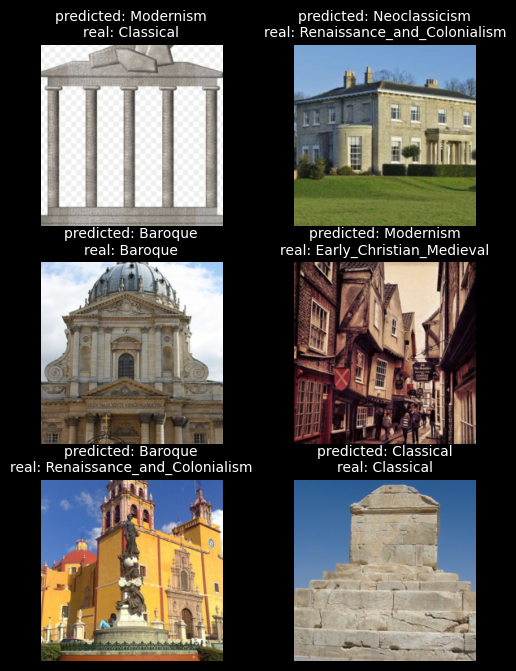

In [5]:
visualize_model(deep_silu_mod, num_images=6, class_names=class_names, vis_loader=vis_loader)

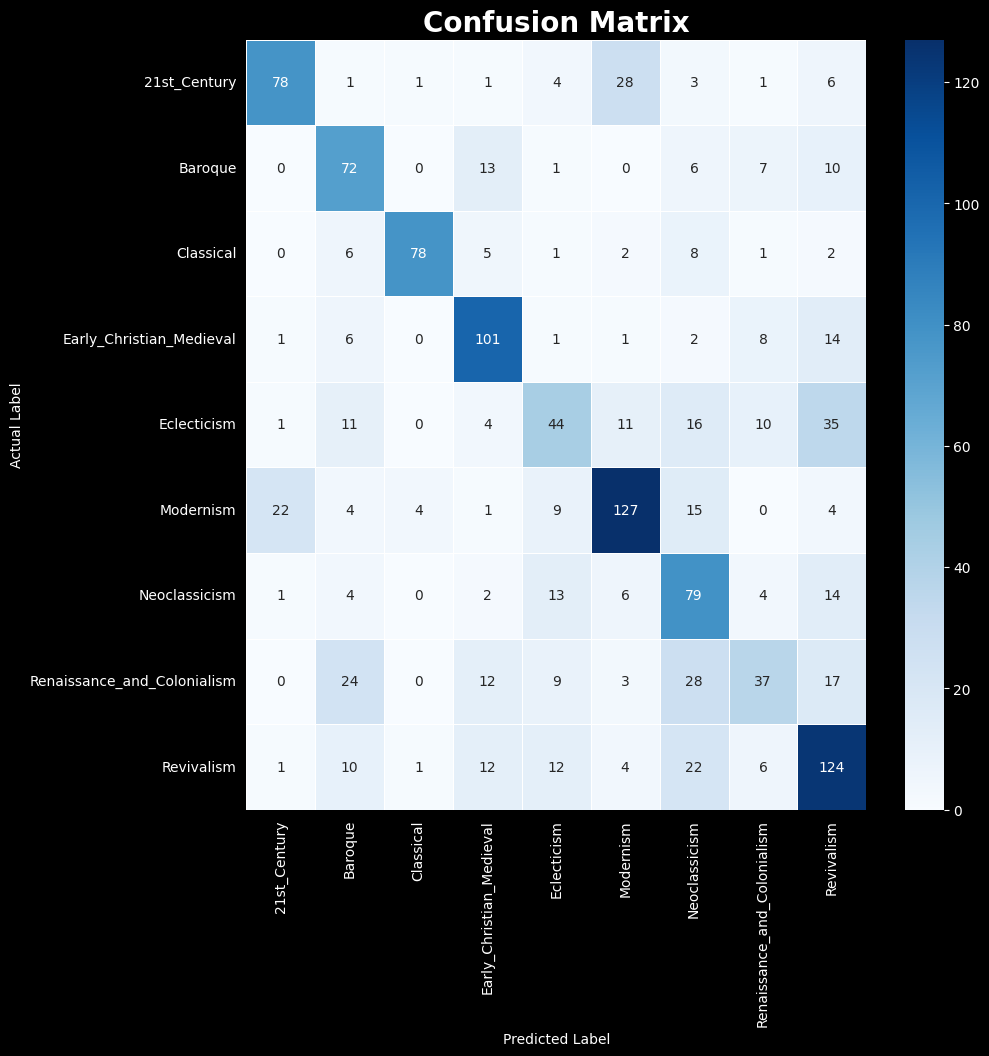

In [6]:
visualize_cm(deep_silu_mod, class_names, test_set)

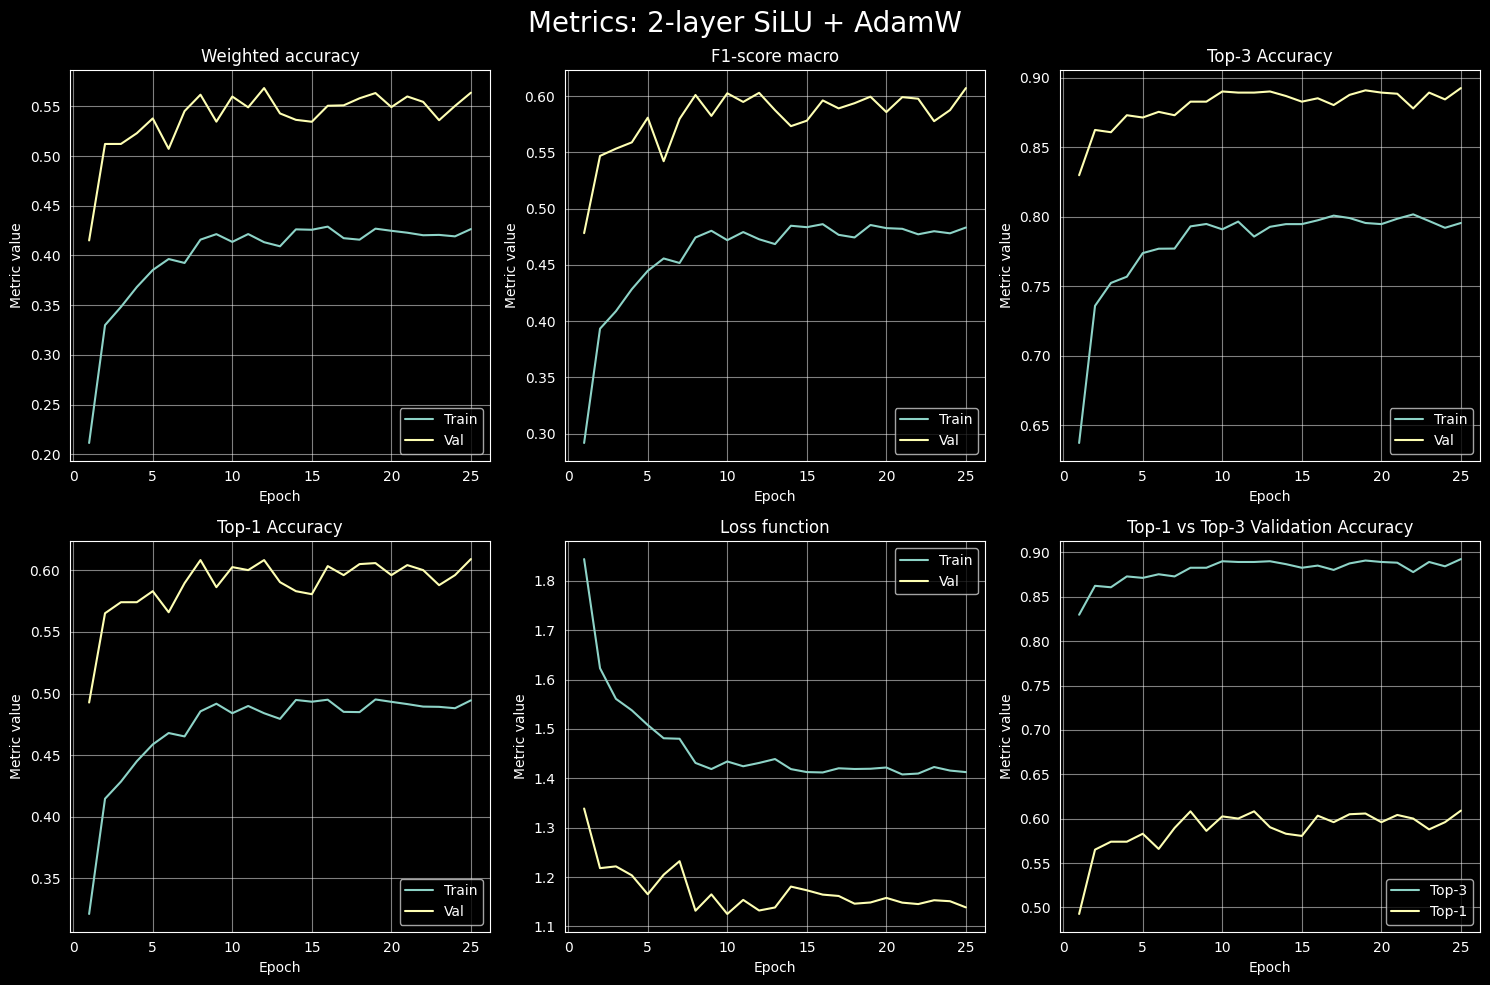

In [25]:
visualize_metrics(metrics_silu, "Metrics: 2-layer SiLU + AdamW", 25)

# lr = 3e-4, weight_decay = 3e-5

In [9]:
cur_mod = deep_silu_mod.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_silu = torch.optim.AdamW(filter(lambda x: x.requires_grad, cur_mod.parameters()), lr=0.0003, weight_decay=0.00003)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_silu, step_size=7, gamma=0.1)

In [10]:
deep_silu_v2, metrics_v2 = train_model(cur_mod, criterion, optimizer_silu, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

val Loss: 1.1025 | Acc: 0.6311 | Weighted Acc: 0.5858 | F1-macro: 0.6329 | Top-1 Acc: 0.6311 | Top-3 Acc: 0.9007
Epoch Time: 18.5228s

Training complete in 7m 49s
Best val Weighted Acc: 0.606203 | Best F1-score: 0.6465 | Best Top-1 Acc: 0.6474 | Best Top-3 Acc: 0.9072


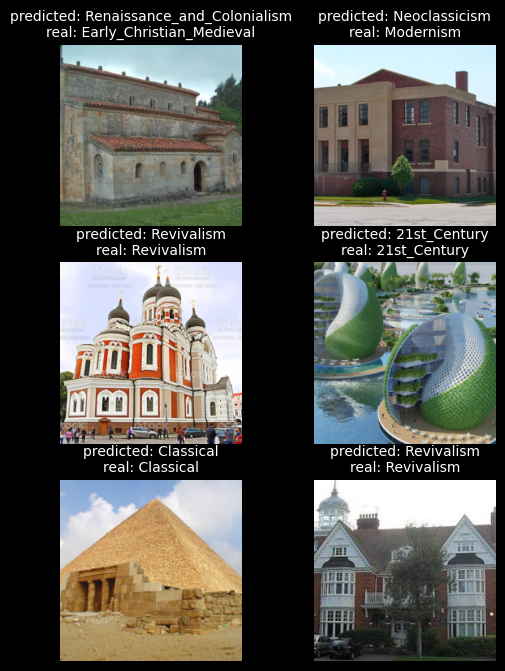

In [11]:
visualize_model(deep_silu_v2, num_images=6, class_names=class_names, vis_loader=vis_loader)

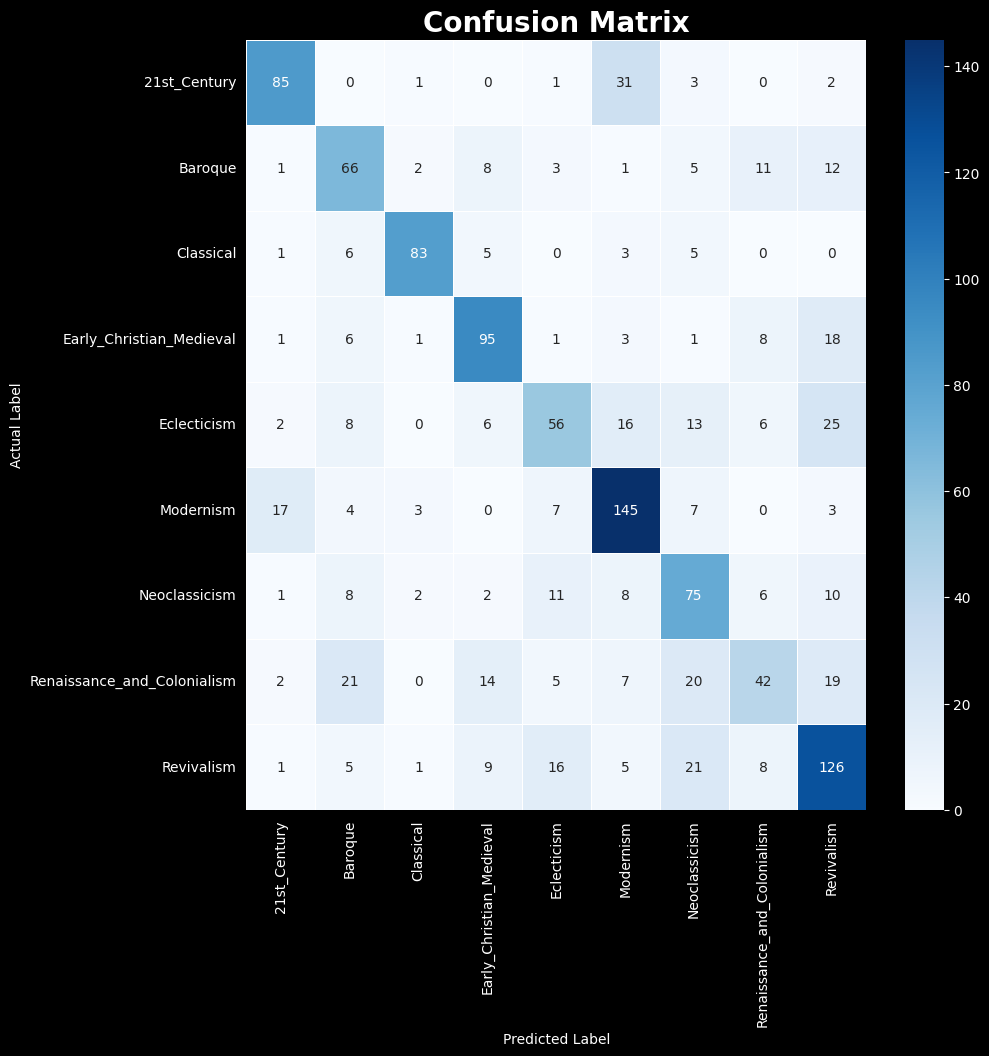

In [12]:
visualize_cm(deep_silu_v2, class_names, test_set)

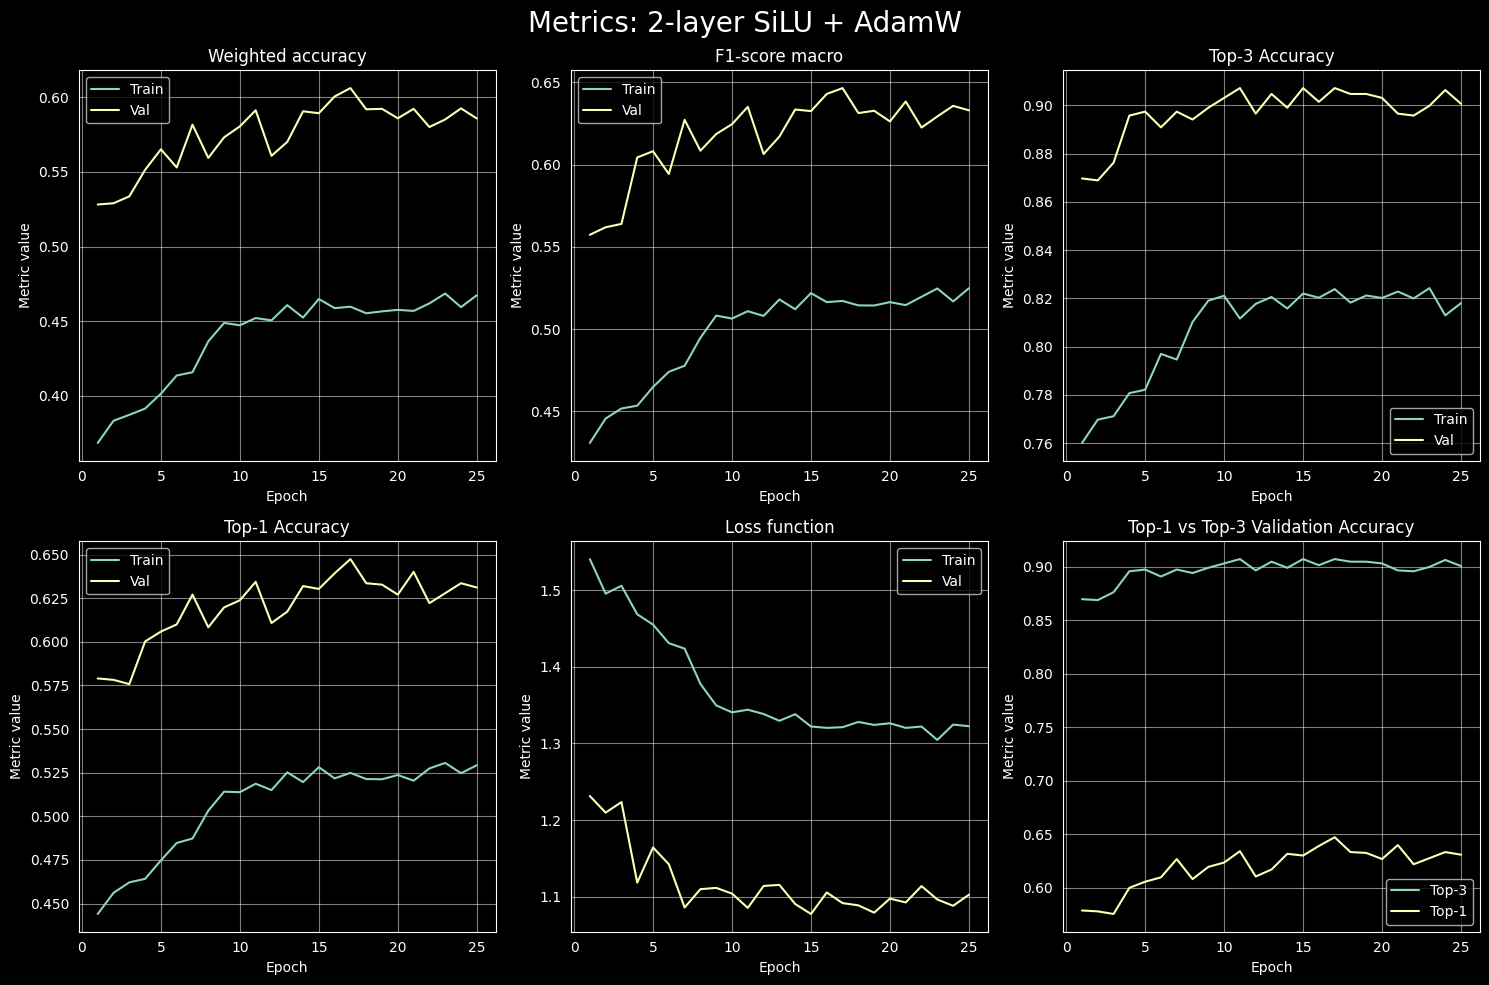

In [26]:
visualize_metrics(metrics_v2, "Metrics: 2-layer SiLU + AdamW", 25)

In [24]:
torch.save(deep_silu_v2, 'deep_silu_adamw.pt')

# lr = 1e-3, weight_decay = 1e-5

In [14]:
cur_mod1 = deep_silu_mod.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_silu = torch.optim.AdamW(filter(lambda x: x.requires_grad, cur_mod1.parameters()), lr=0.001,
                                   weight_decay=0.00001)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_silu, step_size=5, gamma=0.1)
deep_silu_v3, metrics_v3 = train_model(cur_mod1, criterion, optimizer_silu, exp_lr_scheduler, dataloaders, dataset_sizes,
                                       25)

val Loss: 1.1309 | Acc: 0.6262 | Weighted Acc: 0.5831 | F1-macro: 0.6280 | Top-1 Acc: 0.6262 | Top-3 Acc: 0.8917
Epoch Time: 18.8238s

Training complete in 7m 53s
Best val Weighted Acc: 0.602975 | Best F1-score: 0.6380 | Best Top-1 Acc: 0.6393 | Best Top-3 Acc: 0.8860


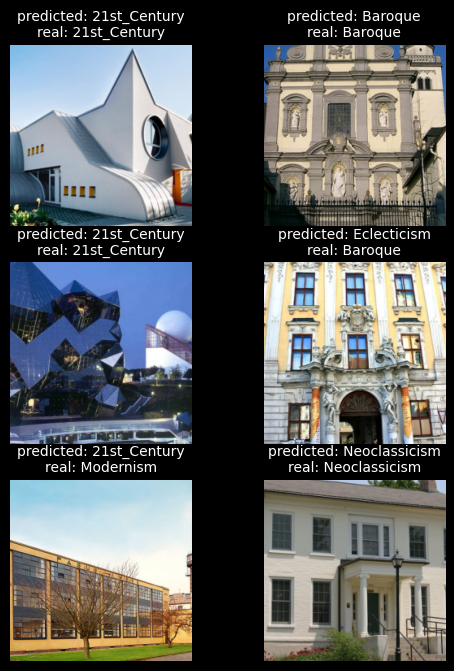

In [15]:
visualize_model(deep_silu_v3, num_images=6, class_names=class_names, vis_loader=vis_loader)

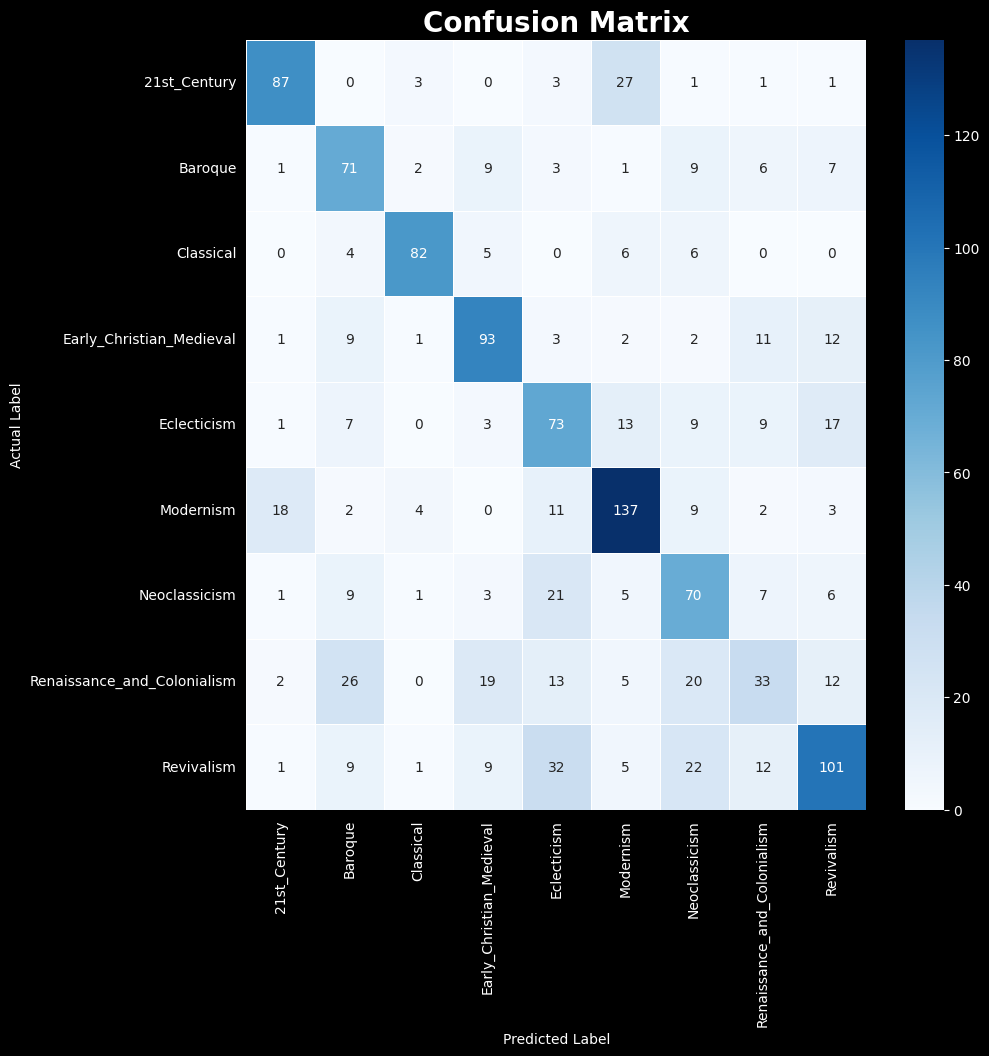

In [16]:
visualize_cm(deep_silu_v3, class_names, test_set)

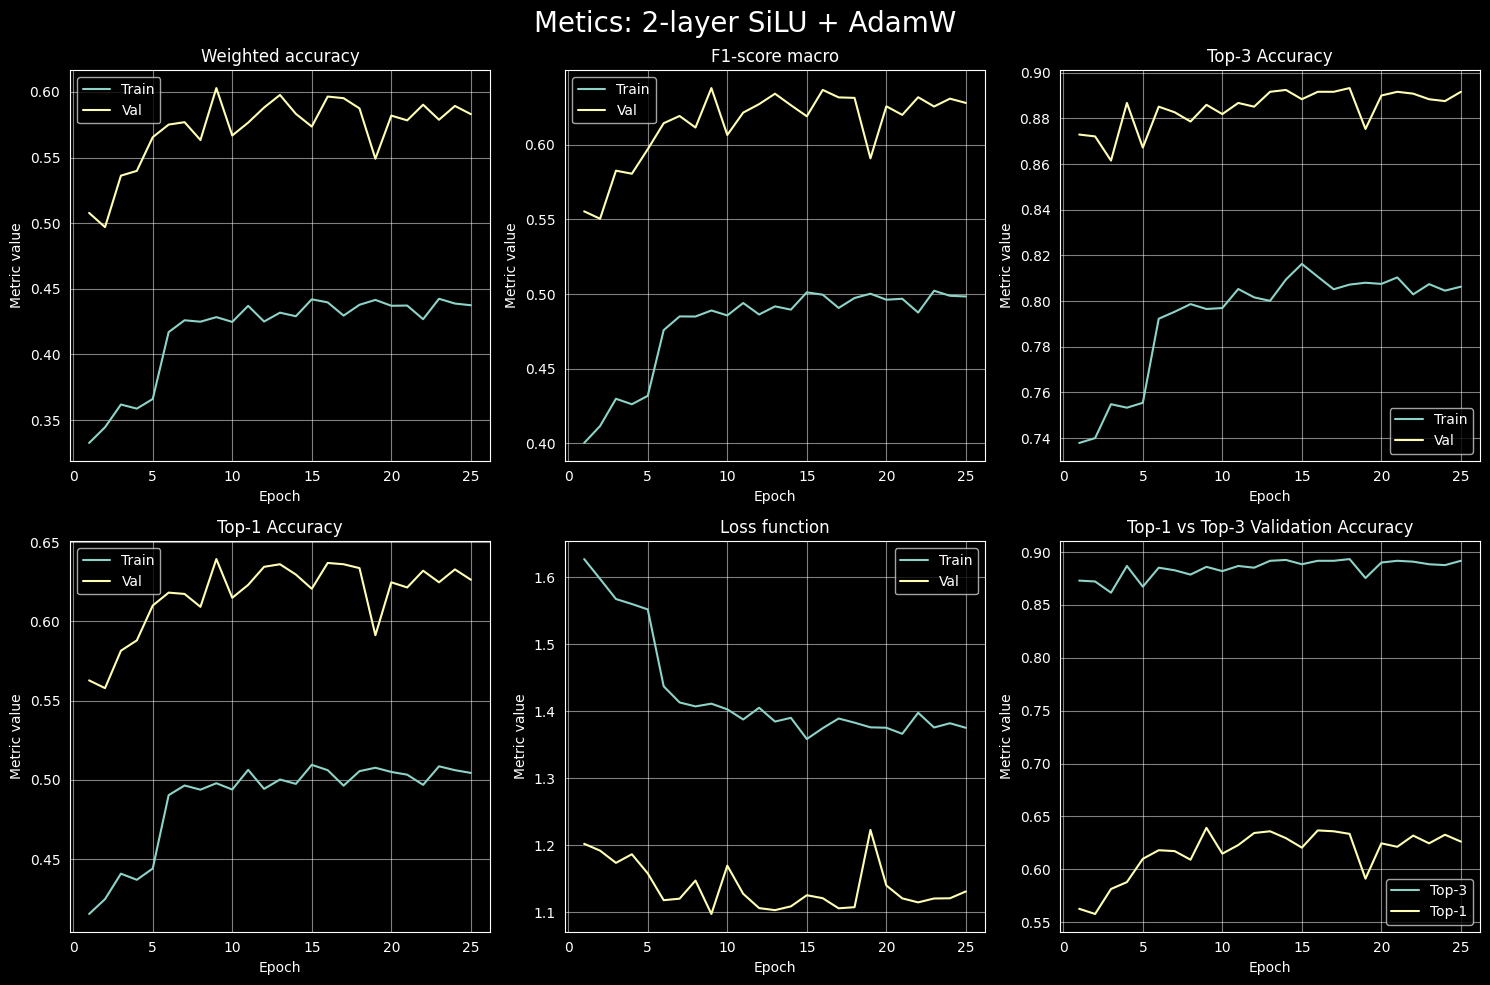

In [17]:
visualize_metrics(metrics_v3, "Metics: 2-layer SiLU + AdamW", 25)

# дообучение модели v2. lr = 1e-4, weight_decay = 3e-5

In [19]:
cur_mod = deep_silu_v2.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_silu = torch.optim.AdamW(filter(lambda x: x.requires_grad, cur_mod.parameters()), lr=0.0001,
                                   weight_decay=0.00003)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_silu, step_size=7, gamma=0.1)
deep_silu_v2_ft, metrics_v2_ft = train_model(cur_mod, criterion, optimizer_silu, exp_lr_scheduler, dataloaders, dataset_sizes,
                                       25)

val Loss: 1.1171 | Acc: 0.6205 | Weighted Acc: 0.5754 | F1-macro: 0.6186 | Top-1 Acc: 0.6205 | Top-3 Acc: 0.8917
Epoch Time: 19.2350s

Training complete in 7m 53s
Best val Weighted Acc: 0.596405 | Best F1-score: 0.6390 | Best Top-1 Acc: 0.6376 | Best Top-3 Acc: 0.8933


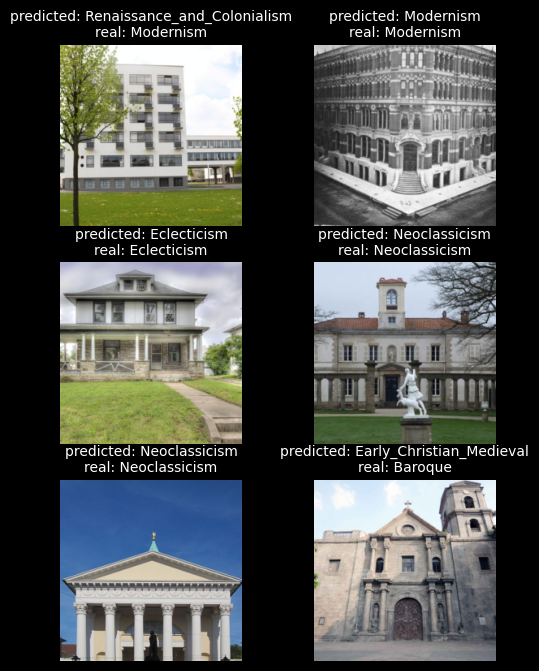

In [20]:
visualize_model(deep_silu_v2_ft, num_images=6, class_names=class_names, vis_loader=vis_loader)

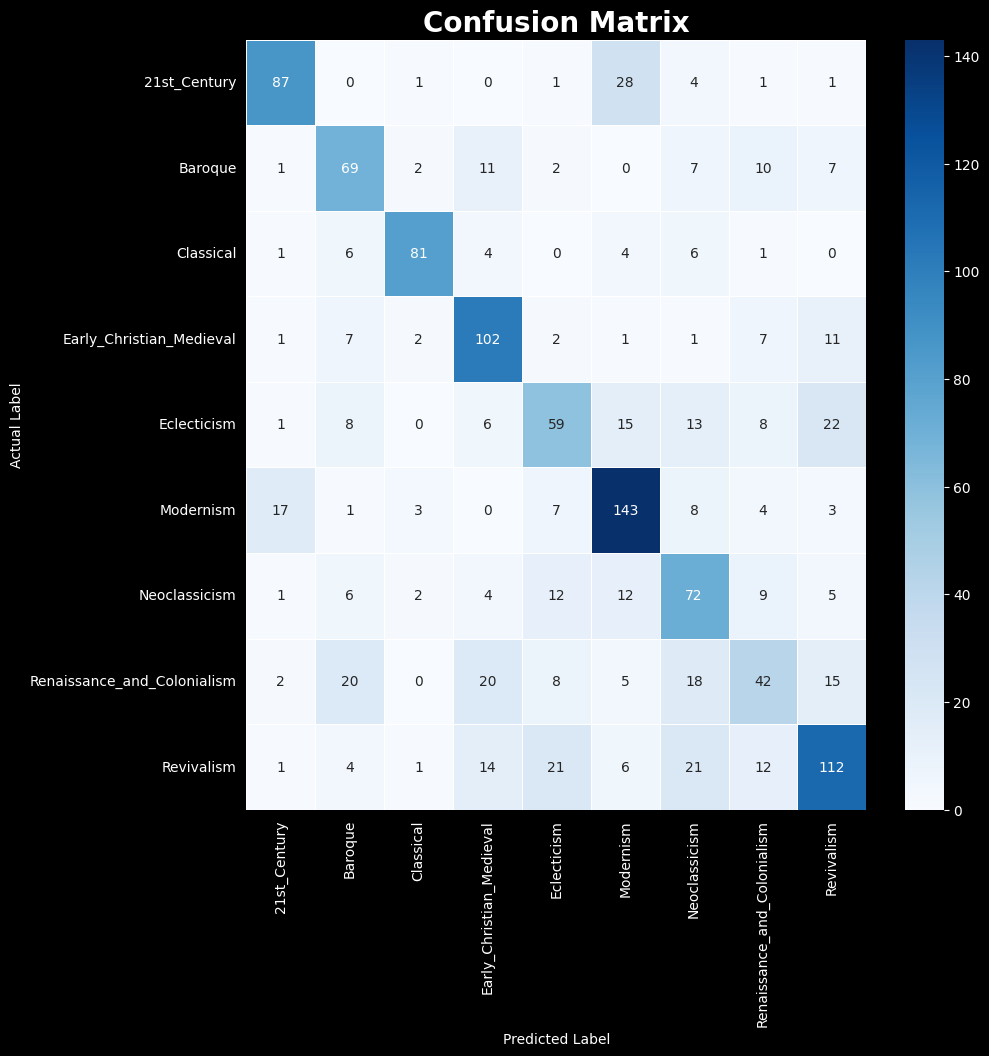

In [21]:
visualize_cm(deep_silu_v2_ft, class_names, test_set)

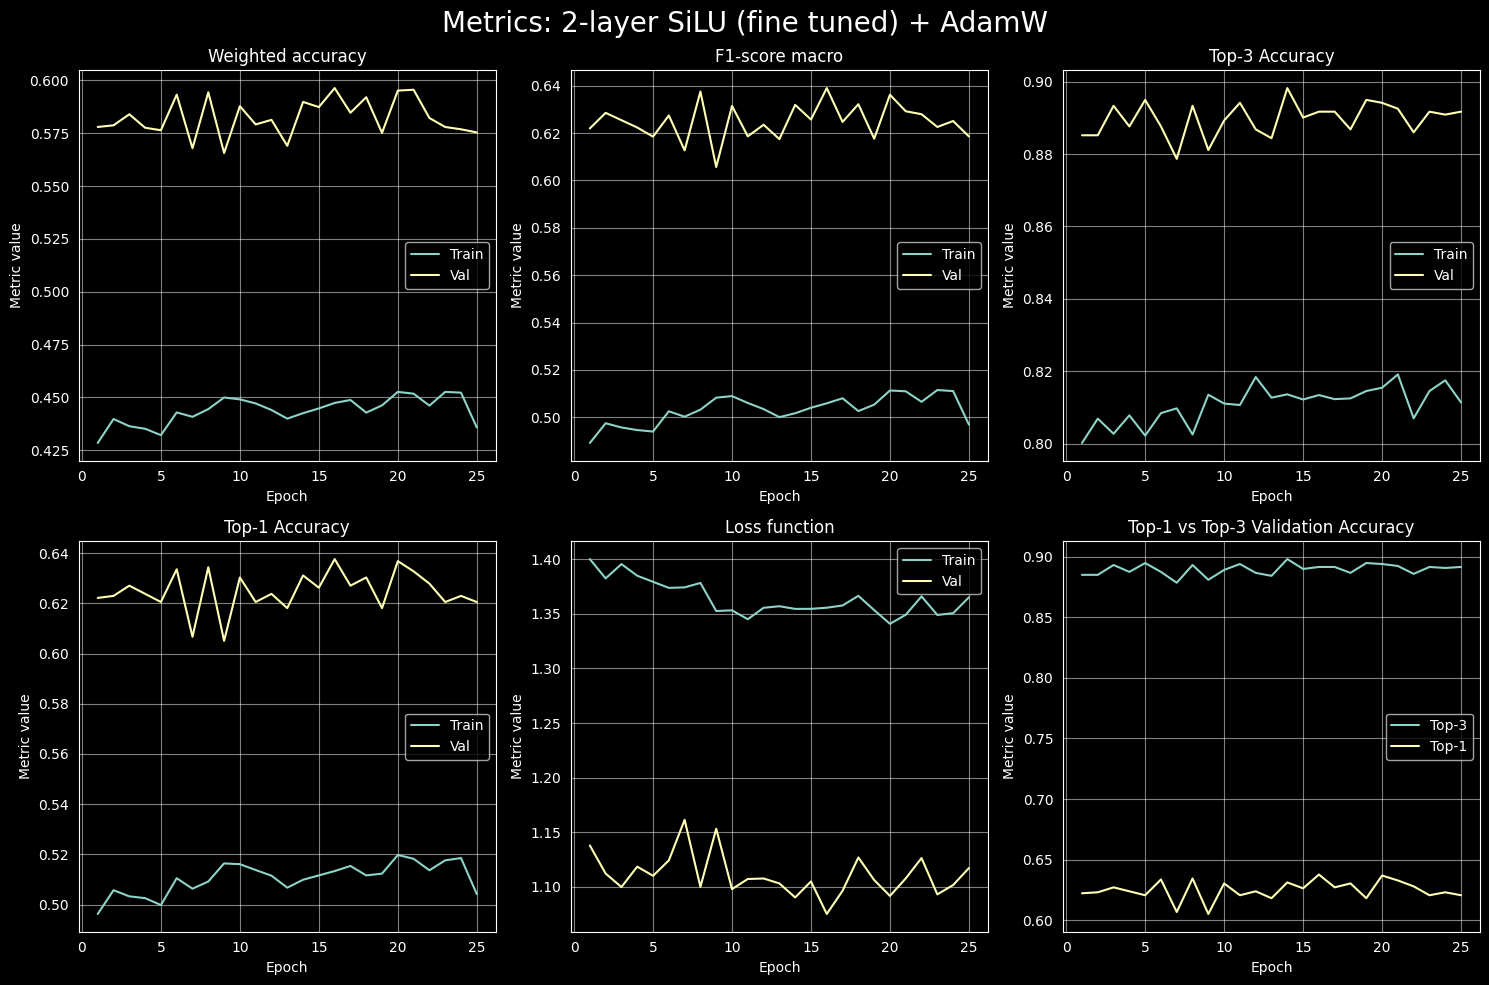

In [27]:
visualize_metrics(metrics_v2_ft, "Metrics: 2-layer SiLU (fine tuned) + AdamW", 25)